# Effects on the acquirer market of the inflation rates

In [5]:
import sys
from datetime import datetime as dt
from functools import reduce

import catppuccin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# from bcrp_analytics.bcrp_analyzer import BCRP_ANALYZER
# from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# TODO: create a visualization.py
plt.style.use(catppuccin.PALETTE.mocha.identifier)

In [6]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent

if not (repo_root / "pyproject.toml").exists():
    raise FileNotFoundError(f"Repository root not found at: {repo_root}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from bcrp_analytics.bcrp_analyzer import BCRP_ANALYZER
from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

# Fetch Data

In [10]:
inflation_series = {
    "PN38705PM": "ipc_general_index",
    "PN38707PM": "ipc_ex_food_energy_index",
    "PN39445PM": "ipc_food_beverages_index",
    # --------------------------------------------------------------
    # Sector inflation — monthly percentage changes
    # These will be chained to create comparable price indexes
    # --------------------------------------------------------------
    "PN01309PM": "fuel_inflation_mom_pct",
    "PN01302PM": "restaurants_inflation_mom_pct",
    "PN01304PM": "health_inflation_mom_pct",
    "PN01310PM": "transport_inflation_mom_pct",
    "PN01299PM": "appliances_inflation_mom_pct",
    # --------------------------------------------------------------
    # Fuel-price shock indicator — real price index, 2010 = 100
    # Useful for the March 2026 event, but not as the main deflator
    # --------------------------------------------------------------
    "PN40408PM": "gasohol_regular_real_price_index",
}

acquiring_market_series = {
    # --------------------------------------------------------------
    # Total acquiring market
    # --------------------------------------------------------------
    "PN42689EM": "gpv_total",
    "PN42698EM": "ntrx_total",
    # --------------------------------------------------------------
    # Pharmacies
    # --------------------------------------------------------------
    "PN42682EM": "gpv_pharmacies",
    "PN42691EM": "ntrx_pharmacies",
    # --------------------------------------------------------------
    # Gas stations — primary focus
    # --------------------------------------------------------------
    "PN42683EM": "gpv_gas_stations",
    "PN42692EM": "ntrx_gas_stations",
    # --------------------------------------------------------------
    # Micro-businesses
    # --------------------------------------------------------------
    "PN42684EM": "gpv_microbusinesses",
    "PN42693EM": "ntrx_microbusinesses",
    # --------------------------------------------------------------
    # Restaurants
    # --------------------------------------------------------------
    "PN42685EM": "gpv_restaurants",
    "PN42694EM": "ntrx_restaurants",
    # --------------------------------------------------------------
    # Supermarkets
    # --------------------------------------------------------------
    "PN42686EM": "gpv_supermarkets",
    "PN42695EM": "ntrx_supermarkets",
    # --------------------------------------------------------------
    # Transportation
    # --------------------------------------------------------------
    "PN42687EM": "gpv_transportation",
    "PN42696EM": "ntrx_transportation",
    # --------------------------------------------------------------
    # Other segments
    # --------------------------------------------------------------
    "PN42688EM": "gpv_other_segments",
    "PN42697EM": "ntrx_other_segments",
}

In [40]:
inflation_data = build_bcrp_dataset(inflation_series)

acquiring_data = build_bcrp_dataset(acquiring_market_series)

# Orden cronológico: del mes más antiguo al más reciente
inflation_data["period"] = pd.to_datetime(inflation_data["period"])
inflation_data = (
    inflation_data.drop_duplicates(subset="period")
    .sort_values("period")
    .reset_index(drop=True)
)

acquiring_data["period"] = pd.to_datetime(acquiring_data["period"])
acquiring_data = (
    acquiring_data.drop_duplicates(subset="period")
    .sort_values("period")
    .reset_index(drop=True)
)

/Users/luisfernandocorcueraleon/Desktop/code/BCRP-ANALYTICS/bcrp_analytics/utils.py:241: UserWarning: Warning: Some series contain missing ovservations due to selecting series with different data ranges
  warnings.warn(


# Building indices

In [41]:
def build_chained_index(series, base=100):
    """
    Convert monthly percentage changes into a chained price index.
    """
    return (1 + series.fillna(0).div(100)).cumprod() * base


inflation_data["fuel_price_index"] = build_chained_index(
    inflation_data["fuel_inflation_mom_pct"]
)

inflation_data["restaurants_price_index"] = build_chained_index(
    inflation_data["restaurants_inflation_mom_pct"]
)

inflation_data["health_price_index"] = build_chained_index(
    inflation_data["health_inflation_mom_pct"]
)

inflation_data["transport_price_index"] = build_chained_index(
    inflation_data["transport_inflation_mom_pct"]
)

inflation_data["appliances_price_index"] = build_chained_index(
    inflation_data["appliances_inflation_mom_pct"]
)

# Interanual inflation

In [42]:
price_indexes = [
    "ipc_general_index",
    "ipc_ex_food_energy_index",
    "ipc_food_beverages_index",
    "fuel_price_index",
    "restaurants_price_index",
    "health_price_index",
    "transport_price_index",
    "appliances_price_index",
]

for column in price_indexes:
    inflation_data[f"{column}_yoy"] = inflation_data[column].pct_change(
        12, fill_method=None
    )

# Market tickets

In [43]:
segments = {
    "total": ("gpv_total", "ntrx_total"),
    "pharmacies": ("gpv_pharmacies", "ntrx_pharmacies"),
    "gas_stations": ("gpv_gas_stations", "ntrx_gas_stations"),
    "microbusinesses": ("gpv_microbusinesses", "ntrx_microbusinesses"),
    "restaurants": ("gpv_restaurants", "ntrx_restaurants"),
    "supermarkets": ("gpv_supermarkets", "ntrx_supermarkets"),
    "transportation": ("gpv_transportation", "ntrx_transportation"),
    "other_segments": ("gpv_other_segments", "ntrx_other_segments"),
}

for segment, (gpv_column, ntrx_column) in segments.items():

    acquiring_data[f"ticket_{segment}"] = (
        acquiring_data[gpv_column] / acquiring_data[ntrx_column] * 1_000
    )

    acquiring_data[f"{gpv_column}_yoy"] = acquiring_data[gpv_column].pct_change(
        12, fill_method=None
    )

    acquiring_data[f"{ntrx_column}_yoy"] = acquiring_data[ntrx_column].pct_change(
        12, fill_method=None
    )

    acquiring_data[f"ticket_{segment}_yoy"] = acquiring_data[
        f"ticket_{segment}"
    ].pct_change(12, fill_method=None)

In [44]:
analysis_data = acquiring_data.merge(
    inflation_data,
    on="period",
    how="left",
    validate="one_to_one",
)

In [45]:
analysis_data[
    [
        "period",
        "gpv_gas_stations",
        "ntrx_gas_stations",
        "ticket_gas_stations",
        "fuel_price_index",
        "gasohol_regular_real_price_index",
    ]
].tail(12)

,period,gpv_gas_stations,ntrx_gas_stations,ticket_gas_stations,fuel_price_index,gasohol_regular_real_price_index
19,2025-08-01,793.57,"14,279.23",55.58,101.67,83.59
20,2025-09-01,784.06,"14,417.44",54.38,100.58,82.44
21,2025-10-01,814.09,"15,065.14",54.04,99.71,81.45
22,2025-11-01,828.91,"15,496.59",53.49,98.44,80.40
23,2025-12-01,884.24,"16,246.69",54.43,98.40,80.14
24,2026-01-01,842.99,"15,737.08",53.57,97.98,79.67
25,2026-02-01,804.62,"15,108.69",53.26,99.33,81.37
26,2026-03-01,"1,143.50","17,742.29",64.45,119.33,106.08
27,2026-04-01,"1,172.12","18,827.96",62.25,119.83,111.19
28,2026-05-01,"1,187.18","19,267.74",61.62,120.01,112.02


# Analyisis

In [46]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Palette compatible with Catppuccin Mocha
# ------------------------------------------------------------------
AQUA = "#79C2BD"
BLUE = "#7798D1"
ORANGE = "#D8A66A"
RED = "#F08080"
PURPLE = "#B59DF0"
GRAY = "#9CA3B5"

TEXT = "#D5D9EE"
GRID = "#5C6172"

SHOCK_DATE = pd.Timestamp("2026-03-01")

analysis_data = analysis_data.sort_values("period").copy()

inflation_data = inflation_data.sort_values("period").copy()


def format_time_axis(
    ax,
    interval=3,
    percent=False,
    percent_base=1,
):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=interval))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax.tick_params(
        axis="both",
        colors=TEXT,
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
    )

    if percent:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(percent_base))

    ax.grid(
        axis="y",
        color=GRID,
        linewidth=0.7,
        alpha=0.30,
    )

    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.margins(x=0.02)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.25)
    ax.spines["bottom"].set_alpha(0.25)

## 1. Agg inflation

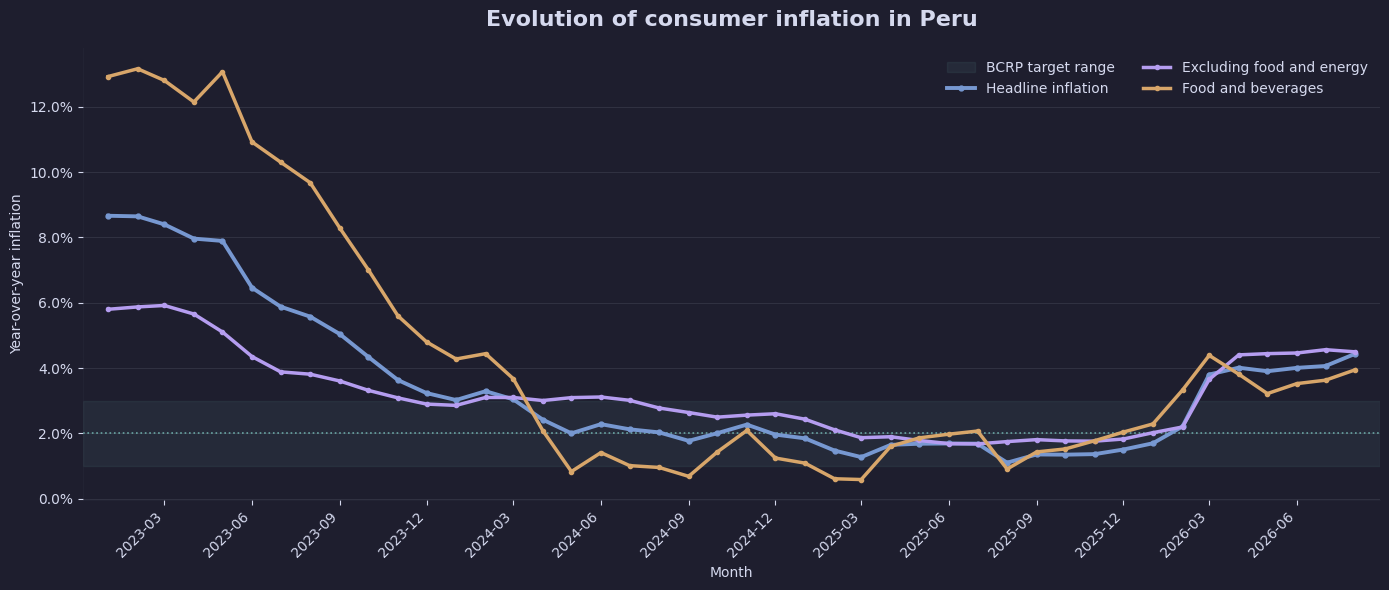

In [47]:
inflation_plot = inflation_data.loc[inflation_data["period"] >= "2023-01-01"].copy()

fig, ax = plt.subplots(figsize=(14, 6))

# BCRP inflation target range: 1%–3%
ax.axhspan(
    0.01,
    0.03,
    color=AQUA,
    alpha=0.08,
    label="BCRP target range",
)

ax.axhline(
    0.02,
    color=AQUA,
    linestyle=":",
    linewidth=1.2,
    alpha=0.8,
)

ax.plot(
    inflation_plot["period"],
    inflation_plot["ipc_general_index_yoy"],
    color=BLUE,
    linewidth=2.8,
    marker="o",
    markersize=3.5,
    label="Headline inflation",
)

ax.plot(
    inflation_plot["period"],
    inflation_plot["ipc_ex_food_energy_index_yoy"],
    color=PURPLE,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Excluding food and energy",
)

ax.plot(
    inflation_plot["period"],
    inflation_plot["ipc_food_beverages_index_yoy"],
    color=ORANGE,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Food and beverages",
)

ax.set_title(
    "Evolution of consumer inflation in Peru",
    fontsize=16,
    fontweight="bold",
    color=TEXT,
    pad=16,
)

ax.set_ylabel(
    "Year-over-year inflation",
    color=TEXT,
)

ax.set_xlabel(
    "Month",
    color=TEXT,
)

ax.legend(
    frameon=False,
    loc="upper right",
    ncol=2,
    labelcolor=TEXT,
)

format_time_axis(
    ax,
    interval=3,
    percent=True,
    percent_base=1,
)

plt.tight_layout()
plt.show()

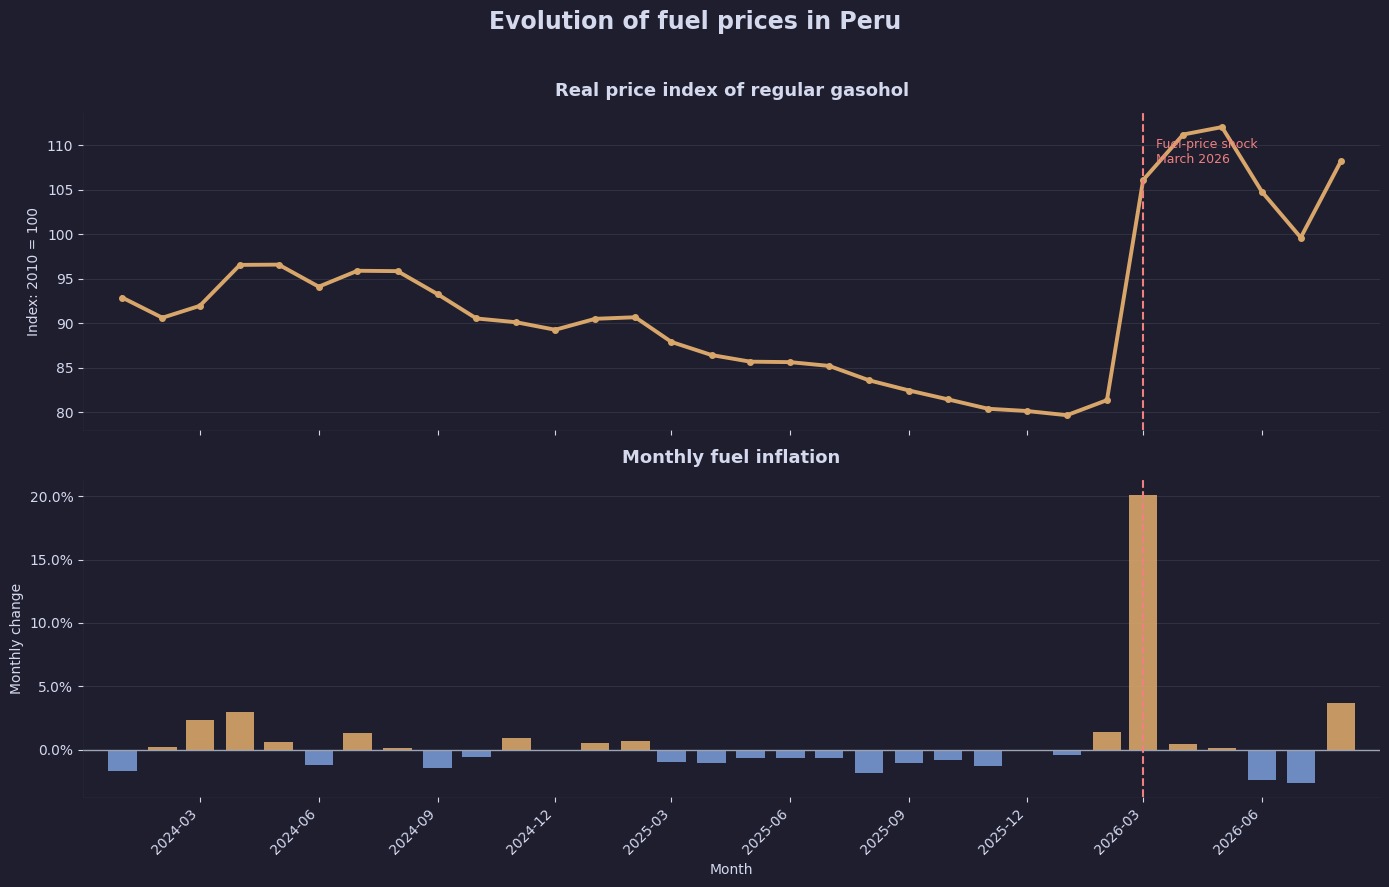

In [48]:
fuel_plot = inflation_data.loc[inflation_data["period"] >= "2024-01-01"].copy()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
)

fig.suptitle(
    "Evolution of fuel prices in Peru",
    fontsize=17,
    fontweight="bold",
    color=TEXT,
    y=0.98,
)

# ==================================================================
# Real gasohol price index
# ==================================================================
axes[0].plot(
    fuel_plot["period"],
    fuel_plot["gasohol_regular_real_price_index"],
    color=ORANGE,
    linewidth=2.8,
    marker="o",
    markersize=4,
)

axes[0].axvline(
    SHOCK_DATE,
    color=RED,
    linestyle="--",
    linewidth=1.5,
)

axes[0].text(
    SHOCK_DATE + pd.DateOffset(days=10),
    0.92,
    "Fuel-price shock\nMarch 2026",
    transform=axes[0].get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=9,
    color=RED,
)

axes[0].set_title(
    "Real price index of regular gasohol",
    fontsize=13,
    fontweight="bold",
    color=TEXT,
    pad=12,
)

axes[0].set_ylabel(
    "Index: 2010 = 100",
    color=TEXT,
)

# ==================================================================
# Monthly fuel inflation
# ==================================================================
bar_colors = np.where(
    fuel_plot["fuel_inflation_mom_pct"] >= 0,
    ORANGE,
    BLUE,
)

axes[1].bar(
    fuel_plot["period"],
    fuel_plot["fuel_inflation_mom_pct"],
    width=22,
    color=bar_colors,
    alpha=0.90,
)

axes[1].axhline(
    0,
    color=GRAY,
    linewidth=1,
)

axes[1].axvline(
    SHOCK_DATE,
    color=RED,
    linestyle="--",
    linewidth=1.5,
)

axes[1].set_title(
    "Monthly fuel inflation",
    fontsize=13,
    fontweight="bold",
    color=TEXT,
    pad=12,
)

axes[1].set_ylabel(
    "Monthly change",
    color=TEXT,
)

axes[1].set_xlabel(
    "Month",
    color=TEXT,
)

for ax in axes:
    format_time_axis(
        ax,
        interval=3,
    )

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(100))

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

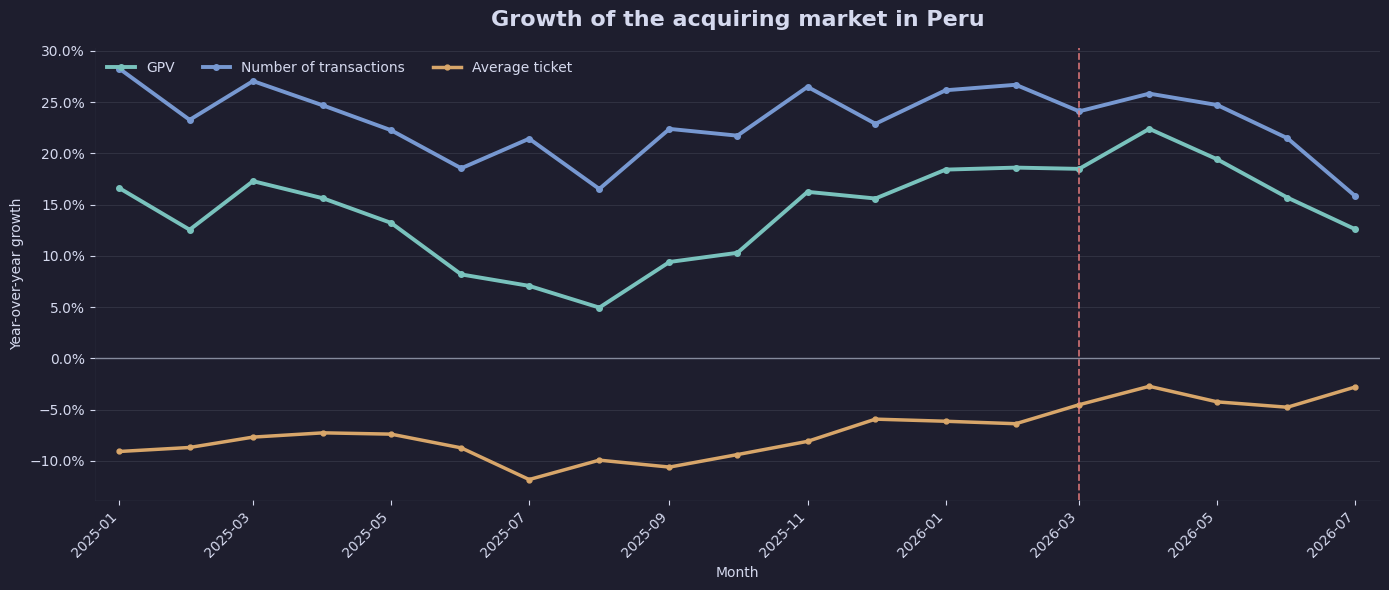

In [49]:
market_plot = analysis_data.loc[analysis_data["period"] >= "2025-01-01"].copy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.axhline(
    0,
    color=GRAY,
    linewidth=1,
    alpha=0.8,
)

ax.plot(
    market_plot["period"],
    market_plot["gpv_total_yoy"],
    color=AQUA,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="GPV",
)

ax.plot(
    market_plot["period"],
    market_plot["ntrx_total_yoy"],
    color=BLUE,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Number of transactions",
)

ax.plot(
    market_plot["period"],
    market_plot["ticket_total_yoy"],
    color=ORANGE,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Average ticket",
)

ax.axvline(
    SHOCK_DATE,
    color=RED,
    linestyle="--",
    linewidth=1.3,
    alpha=0.8,
)

ax.set_title(
    "Growth of the acquiring market in Peru",
    fontsize=16,
    fontweight="bold",
    color=TEXT,
    pad=16,
)

ax.set_ylabel(
    "Year-over-year growth",
    color=TEXT,
)

ax.set_xlabel(
    "Month",
    color=TEXT,
)

ax.legend(
    frameon=False,
    loc="upper left",
    ncol=3,
    labelcolor=TEXT,
)

format_time_axis(
    ax,
    interval=2,
    percent=True,
    percent_base=1,
)

plt.tight_layout()
plt.show()

In [50]:
gas_plot = (
    analysis_data.loc[analysis_data["period"] >= "2024-01-01"]
    .dropna(
        subset=[
            "gpv_gas_stations",
            "ntrx_gas_stations",
            "ticket_gas_stations",
            "fuel_price_index",
        ]
    )
    .copy()
)

base_row = gas_plot.iloc[0]

gas_plot["fuel_price_normalized"] = (
    gas_plot["fuel_price_index"] / base_row["fuel_price_index"] * 100
)

gas_plot["gas_ticket_normalized"] = (
    gas_plot["ticket_gas_stations"] / base_row["ticket_gas_stations"] * 100
)

gas_plot["gas_gpv_normalized"] = (
    gas_plot["gpv_gas_stations"] / base_row["gpv_gas_stations"] * 100
)

gas_plot["gas_ntrx_normalized"] = (
    gas_plot["ntrx_gas_stations"] / base_row["ntrx_gas_stations"] * 100
)

# Approximate real GPV:
# nominal GPV divided by the relative fuel-price index
gas_plot["gas_real_gpv_normalized"] = gas_plot["gas_gpv_normalized"] / (
    gas_plot["fuel_price_normalized"] / 100
)

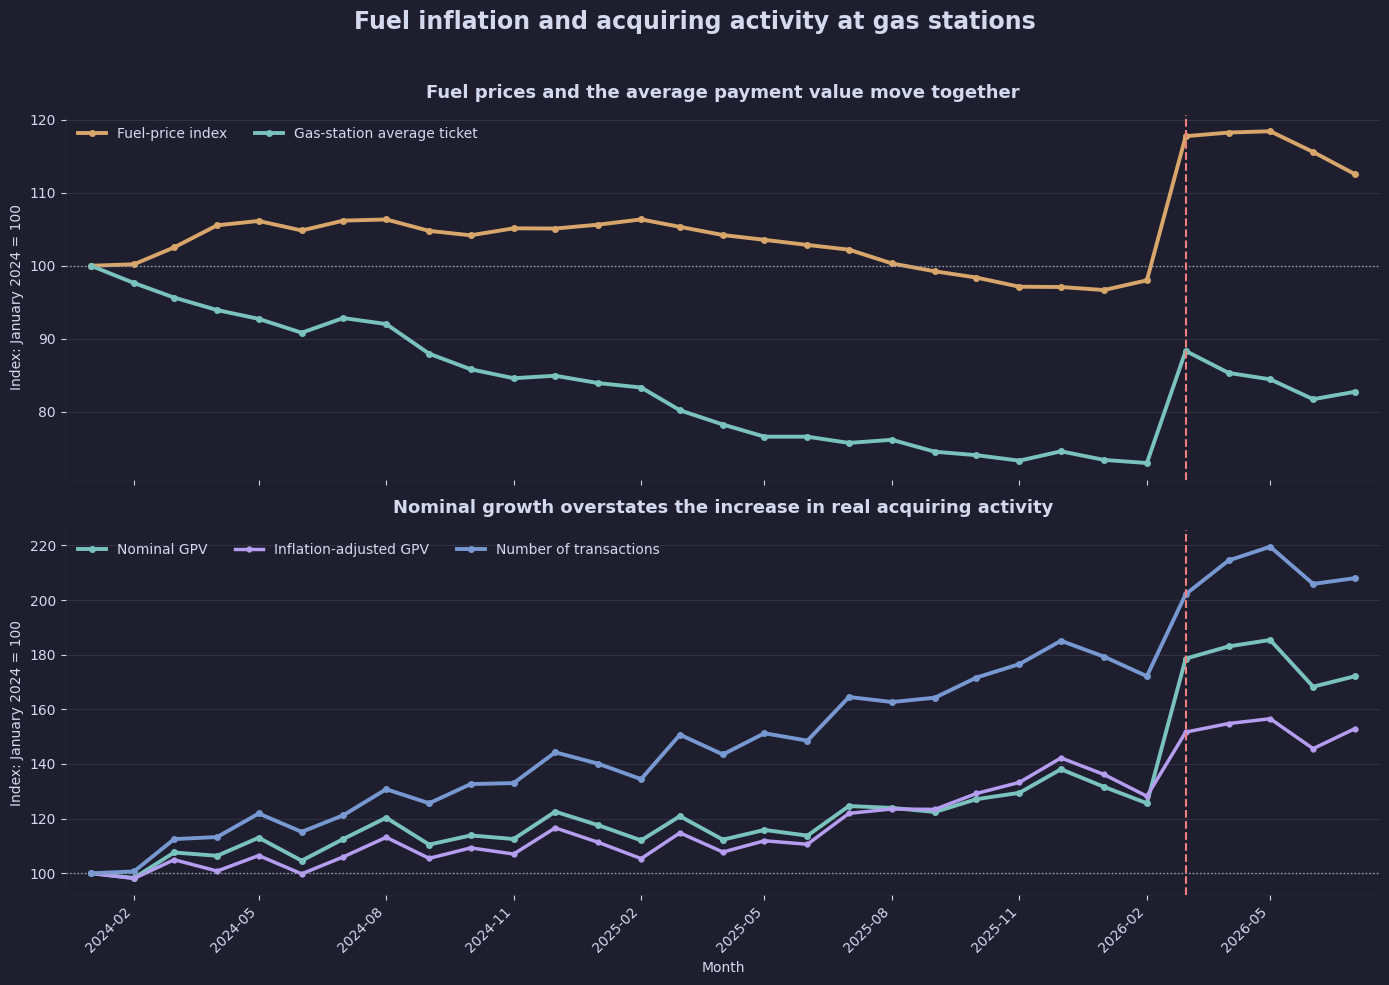

In [51]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
)

fig.suptitle(
    "Fuel inflation and acquiring activity at gas stations",
    fontsize=17,
    fontweight="bold",
    color=TEXT,
    y=0.98,
)

# ==================================================================
# Plot 1: Fuel prices versus average ticket
# ==================================================================
axes[0].plot(
    gas_plot["period"],
    gas_plot["fuel_price_normalized"],
    color=ORANGE,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Fuel-price index",
)

axes[0].plot(
    gas_plot["period"],
    gas_plot["gas_ticket_normalized"],
    color=AQUA,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Gas-station average ticket",
)

axes[0].axhline(
    100,
    color=GRAY,
    linestyle=":",
    linewidth=1,
)

axes[0].axvline(
    SHOCK_DATE,
    color=RED,
    linestyle="--",
    linewidth=1.5,
)

axes[0].set_title(
    "Fuel prices and the average payment value move together",
    fontsize=13,
    fontweight="bold",
    color=TEXT,
    pad=12,
)

axes[0].set_ylabel(
    "Index: January 2024 = 100",
    color=TEXT,
)

axes[0].legend(
    frameon=False,
    loc="upper left",
    ncol=2,
    labelcolor=TEXT,
)

# ==================================================================
# Plot 2: Nominal GPV, real GPV and transactions
# ==================================================================
axes[1].plot(
    gas_plot["period"],
    gas_plot["gas_gpv_normalized"],
    color=AQUA,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Nominal GPV",
)

axes[1].plot(
    gas_plot["period"],
    gas_plot["gas_real_gpv_normalized"],
    color=PURPLE,
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="Inflation-adjusted GPV",
)

axes[1].plot(
    gas_plot["period"],
    gas_plot["gas_ntrx_normalized"],
    color=BLUE,
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Number of transactions",
)

axes[1].axhline(
    100,
    color=GRAY,
    linestyle=":",
    linewidth=1,
)

axes[1].axvline(
    SHOCK_DATE,
    color=RED,
    linestyle="--",
    linewidth=1.5,
)

axes[1].set_title(
    "Nominal growth overstates the increase in real acquiring activity",
    fontsize=13,
    fontweight="bold",
    color=TEXT,
    pad=12,
)

axes[1].set_ylabel(
    "Index: January 2024 = 100",
    color=TEXT,
)

axes[1].set_xlabel(
    "Month",
    color=TEXT,
)

axes[1].legend(
    frameon=False,
    loc="upper left",
    ncol=3,
    labelcolor=TEXT,
)

for ax in axes:
    format_time_axis(
        ax,
        interval=3,
    )

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [52]:
gas_plot.loc[
    gas_plot["period"].between(
        "2026-01-01",
        "2026-07-01",
    ),
    [
        "period",
        "gpv_gas_stations",
        "ntrx_gas_stations",
        "ticket_gas_stations",
        "fuel_price_index",
        "gasohol_regular_real_price_index",
        "gas_gpv_normalized",
        "gas_real_gpv_normalized",
    ],
]

,period,gpv_gas_stations,ntrx_gas_stations,ticket_gas_stations,fuel_price_index,gasohol_regular_real_price_index,gas_gpv_normalized,gas_real_gpv_normalized
24,2026-01-01,842.99,"15,737.08",53.57,97.98,79.67,131.64,136.17
25,2026-02-01,804.62,"15,108.69",53.26,99.33,81.37,125.65,128.21
26,2026-03-01,"1,143.50","17,742.29",64.45,119.33,106.08,178.57,151.67
27,2026-04-01,"1,172.12","18,827.96",62.25,119.83,111.19,183.04,154.81
28,2026-05-01,"1,187.18","19,267.74",61.62,120.01,112.02,185.39,156.57
29,2026-06-01,"1,077.68","18,072.99",59.63,117.14,104.75,168.29,145.61
30,2026-07-01,"1,102.09","18,256.62",60.37,114.08,99.62,172.11,152.91
